# Read H-Reflex App Data Files (.hrs1 and .hrs2)

This notebook reads and visualizes data from the **H-Reflex Behavior App** binary data files:

- **`.hrs1`**  EMG Characterization stage data (Stage S1): contains trial-initiation monitored signals, binned EMG, and grand means.
- **`.hrs2`** MH Recruitment Curve stage data (Stage S2): contains peri-stimulus trial waveforms with stimulation amplitudes.

Both file types also store raw EMG data blocks (differential, filtered, absolute-valued signals).

The binary format is based on the `FileIO_Helpers` serialization from the `hreflex_txbdc` package.

# Section 1: Binary File Reader Utilities

In [26]:
import os
import numpy as np
import matplotlib.pyplot as plt
import glob as globmod
from IPython.display import display
from helpers import (
    # HRS file readers
    read_hrs1, read_hrs2, find_hrs_files,
    # HRS signal helpers
    detect_stim_onset, get_trial_window, classify_trials,
    # HRS data classes
    EmgCharHeader, EmgCharTrial, EmgDataBlock, EmgTrialsPerHourData, MhRecHeader, MhRecTrial,
    # HRS constants
    SAMPLE_RATE, BIN_DURATION_MS, BIN_SAMPLES, TRIAL_RECORD_MS,
    TRIAL_RECORD_SAMPLES, MS_PER_SAMPLE,
    STIM_ONSET_THRESHOLD, STIM_END_THRESHOLD,
    BLOCK_EMG_DATA, BLOCK_EMG_CHAR_TRIAL, BLOCK_MH_TRIAL, BLOCK_EMG_TRIALS_PER_HOUR,
)

print("Binary reader utilities loaded.")
print(f"  App constants: SAMPLE_RATE={SAMPLE_RATE} Hz | BIN={BIN_DURATION_MS} ms ({BIN_SAMPLES} samples) | TRIAL_RECORD={TRIAL_RECORD_MS} ms")
print(f"  Stim thresholds: onset >= {STIM_ONSET_THRESHOLD} V | end < {STIM_END_THRESHOLD} V")

Binary reader utilities loaded.
  App constants: SAMPLE_RATE=5000.0 Hz | BIN=50 ms (250 samples) | TRIAL_RECORD=100 ms
  Stim thresholds: onset >= 4.5 V | end < 1.9 V


# Section 2: Read and Explore the HRS1 File (EMG Characterization)

# Section 1b: Auto-Detect Recording Files

Set `recording_dir` to the path of your recording folder.  
The `.hrs1` and `.hrs2` files will be found automatically.

In [45]:
# ---- Set your recording directory here ----
# Set to the folder that contains your .hrs1 (and optionally .hrs2) files.
#
# New-format HRPILOT recordings (HRS1 includes sample_rate field):
#   HRPILOT-14-CONFIGA_RECRUITMENTCURVE_      -- first recruitment curve  (HRS2 v2)
#   HRPILOT-14-CONFIGA_2ND_RECRUITMENTCURVE_  -- second recruitment curve (HRS2 v3, unipolar)
#   HRPILOT-15-CONFIGA_RECRUITMENTCURVE_      -- first recruitment curve  (HRS2 v2)
#   HRPILOT-15-CONFIGA_2ND_RECRUITMENTCURVE_  -- second recruitment curve (HRS2 v3, unipolar)
#   HRPILOT-16-CONFIGA_RECRUITMENTCURVE_      -- first recruitment curve  (HRS2 v2)
#   HRPILOT-16-CONFIGA_2ND_RECRUITMENTCURVE_  -- second recruitment curve (HRS2 v3, unipolar)
#
# Legacy polarity / hour-test recordings (no sample_rate in HRS1 header):
#   Polarity_Tests/HR-08-POLARITY_TEST_CORRECT   -- electrodes attached correctly
#   Polarity_Tests/HR-08-POLARITY_TEST_FLIPPED_  -- electrodes attached flipped
#   Polarity_Tests/HR-08-HOUR_TEST_              -- HRS1 only (no HRS2 file)

recording_dir = "HRPILOT-16_CONFIGA_POSTHOC_WINDOWING"

hrs1_path, hrs2_path = find_hrs_files(recording_dir)
print(f"Recording directory: {recording_dir}")
print(f"  HRS1 file: {os.path.basename(hrs1_path)}")
if hrs2_path is not None:
    print(f"  HRS2 file: {os.path.basename(hrs2_path)}")
else:
    print("  HRS2 file: not found — HRS2 sections will be skipped")


Recording directory: HRPILOT-16_CONFIGA_POSTHOC_WINDOWING
  HRS1 file: HRPILOT-16_CONFIGA_POSTHOC_WINDOWING_20260421T144903.hrs1
  HRS2 file: HRPILOT-16_CONFIGA_POSTHOC_WINDOWING_20260421T144930.hrs2


In [46]:
# ---- Read the HRS1 file (auto-detected) ----
hrs1_header, hrs1_trials, hrs1_emg_blocks = read_hrs1(hrs1_path)

print(f"=== HRS1 Header ===")
print(f"  File:               {os.path.basename(hrs1_path)}")
print(f"  File version:       {hrs1_header.file_version}")
print(f"  Subject ID:         {hrs1_header.subject_id}")
print(f"  Session datetime:   {hrs1_header.session_datetime}")
print(f"  Stage name:         {hrs1_header.stage_name}")
print(f"  Stage description:  {hrs1_header.stage_description}")
print(f"  Stage type:         {hrs1_header.stage_type}")
print(f"  Trial init uV min:  {hrs1_header.trial_initiation_uv_min}")
print(f"  Trial init uV max:  {hrs1_header.trial_initiation_uv_max}")
print(f"  Trial init phase min ms: {hrs1_header.trial_initiation_phase_min_ms}")
print(f"  Trial init phase max ms: {hrs1_header.trial_initiation_phase_max_ms}")
print(f"  Bin duration ms:    {hrs1_header.bin_duration_ms}")
print(f"  Sample rate:        {hrs1_header.sample_rate} Hz")
tph = hrs1_header.trials_per_hour_data
if tph is not None:
    print(f"  Trials/hr data: centre={tph.sweep_centre_uv:.2f} µV, elapsed={tph.elapsed_hours:.3f} h, {len(tph.window_sizes)} window sizes")
else:
    print("  Trials-per-hour data: not present in file")
print(f"\n  Trials found:       {len(hrs1_trials)}")
print(f"  EMG data blocks:    {len(hrs1_emg_blocks)}")

if len(hrs1_trials) > 0:
    print(f"\n=== First Trial ===")
    t0 = hrs1_trials[0]
    print(f"  End datetime:       {t0.trial_end_datetime}")
    print(f"  Start index:        {t0.trial_start_index}")
    print(f"  Grand mean:         {t0.grand_mean:.4f}")
    print(f"  Bins count:         {len(t0.bins)}")
    print(f"  Monitored signal N: {len(t0.monitored_signal)}")

if len(hrs1_emg_blocks) > 0:
    b0 = hrs1_emg_blocks[0]
    print(f"\n=== First EMG Block ===")
    print(f"  Channel names:      {b0.channel_names}")
    print(f"  Raw channels:       {len(b0.raw_channels)} x {len(b0.raw_channels[0]) if b0.raw_channels else 0} samples")
    print(f"  Diff samples:       {len(b0.diff)}")
    print(f"  Filtered samples:   {len(b0.filtered)}")
    print(f"  Abs samples:        {len(b0.abs_val)}")

=== HRS1 Header ===
  File:               HRPILOT-16_CONFIGA_POSTHOC_WINDOWING_20260421T144903.hrs1
  File version:       0
  Subject ID:         HRPILOT-16_CONFIGA_POSTHOC_WINDOWING
  Session datetime:   2026-04-21 14:49:03.971372
  Stage name:         S1
  Stage description:  EMG Characterization
  Stage type:         0
  Trial init uV min:  15.0
  Trial init uV max:  300.0
  Trial init phase min ms: 2200
  Trial init phase max ms: 2700
  Bin duration ms:    50
  Sample rate:        5000.0 Hz
  Trials-per-hour data: not present in file

  Trials found:       1
  EMG data blocks:    339

=== First Trial ===
  End datetime:       2026-04-21 14:49:07.401619
  Start index:        41873
  Grand mean:         298.5854
  Bins count:         51
  Monitored signal N: 12750

=== First EMG Block ===
  Channel names:      ['CH10', 'CH12', 'ADC1']
  Raw channels:       3 x 191 samples
  Diff samples:       191
  Filtered samples:   191
  Abs samples:        191


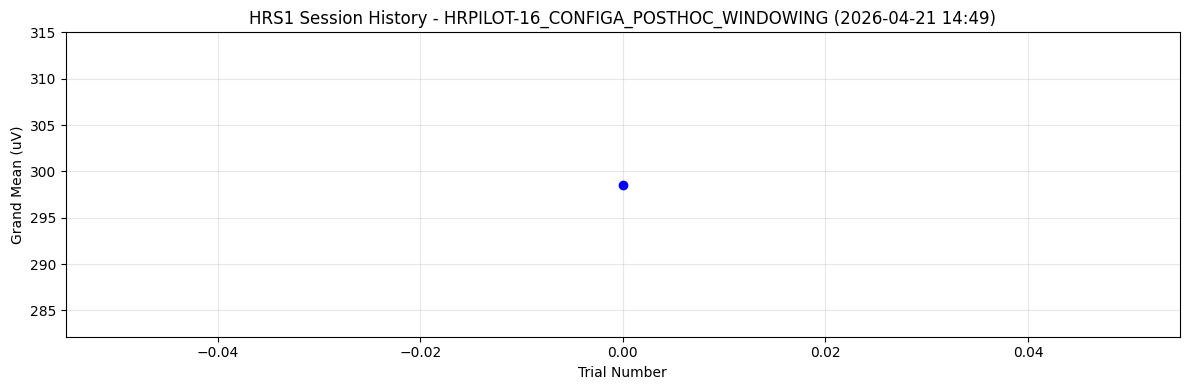

Grand mean range: [298.59, 298.59] uV
Overall mean of grand means: 298.59 uV


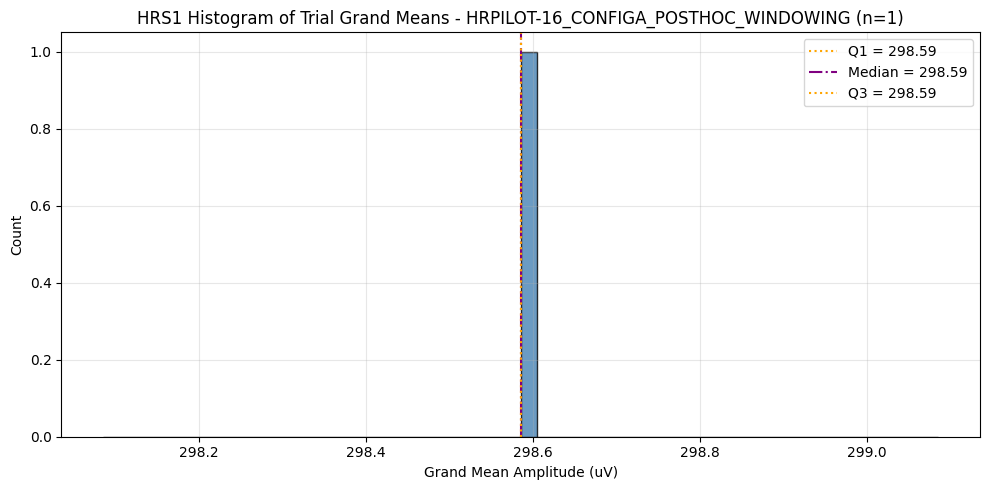

Stats: min=298.59, Q1=298.59, median=298.59, Q3=298.59, max=298.59, std=0.00


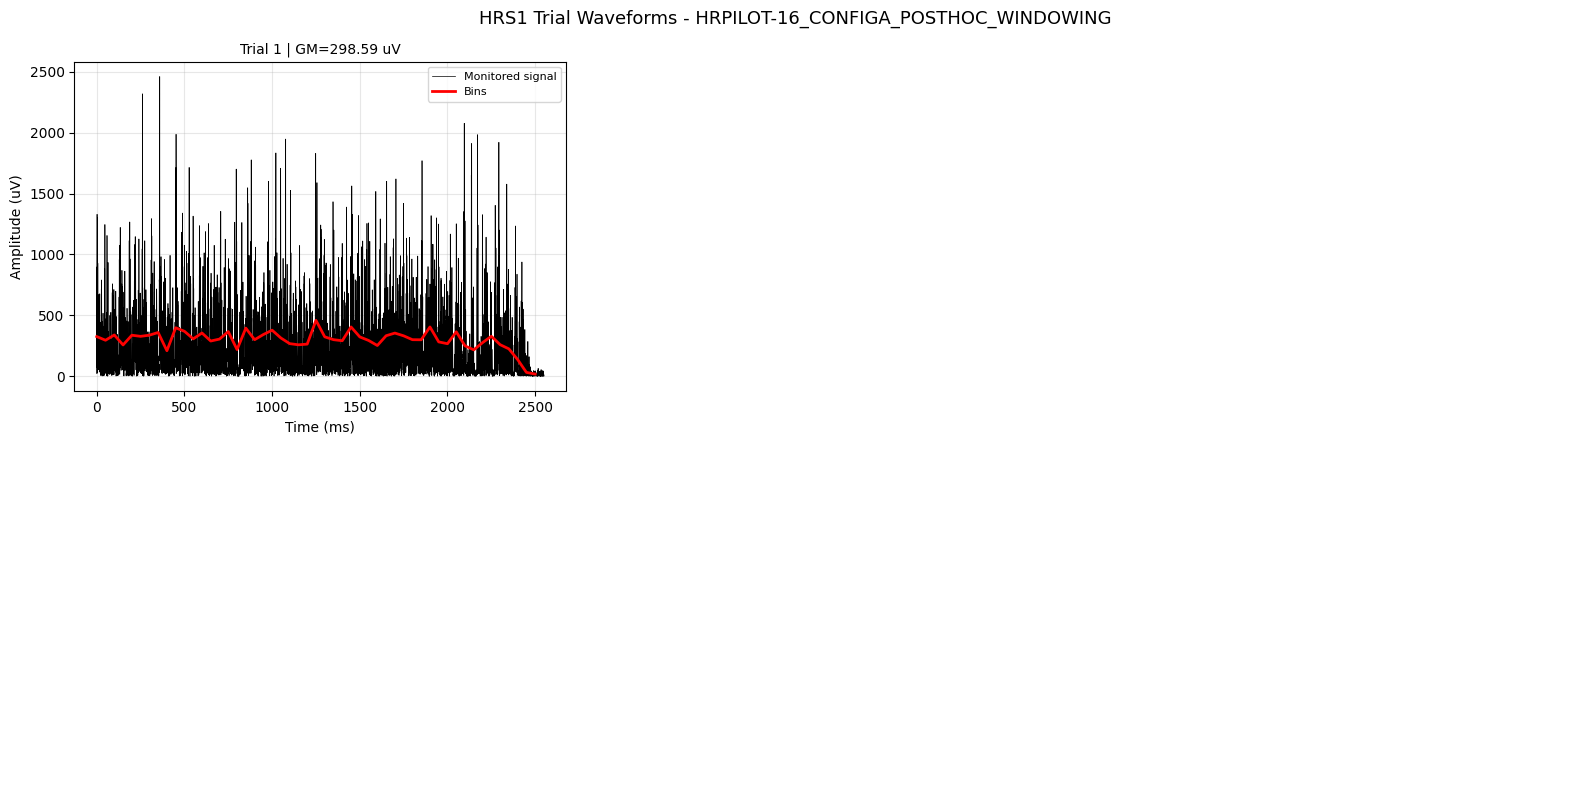

In [47]:
# ---- Plot HRS1: Trial Grand Means (Session History) ----
grand_means = [t.grand_mean for t in hrs1_trials]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(len(grand_means)), grand_means, 'o', color='blue', markersize=6)
ax.set_xlabel('Trial Number')
ax.set_ylabel('Grand Mean (uV)')
ax.set_title(f'HRS1 Session History - {hrs1_header.subject_id} ({hrs1_header.session_datetime:%Y-%m-%d %H:%M})')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Grand mean range: [{min(grand_means):.2f}, {max(grand_means):.2f}] uV")
print(f"Overall mean of grand means: {np.mean(grand_means):.2f} uV")

# ---- Plot HRS1: Histogram of Grand Means ----
gm = np.array(grand_means)

fig, ax = plt.subplots(figsize=(10, 5))
hist_vals, hist_edges, _ = ax.hist(gm, bins=50, color='steelblue', edgecolor='black', alpha=0.8)
#ax.axvline(hrs1_header.trial_initiation_uv_min, color='red', linestyle='--', linewidth=1.5, label=f'Init min = {hrs1_header.trial_initiation_uv_min}')
#ax.axvline(hrs1_header.trial_initiation_uv_max, color='red', linestyle='--', linewidth=1.5, label=f'Init max = {hrs1_header.trial_initiation_uv_max}')

q25, q50, q75 = np.percentile(gm, [25, 50, 75])
ax.axvline(q25, color='orange', linestyle=':', linewidth=1.5, label=f'Q1 = {q25:.2f}')
ax.axvline(q50, color='purple', linestyle='-.', linewidth=1.5, label=f'Median = {q50:.2f}')
ax.axvline(q75, color='orange', linestyle=':', linewidth=1.5, label=f'Q3 = {q75:.2f}')

ax.set_xlabel('Grand Mean Amplitude (uV)')
ax.set_ylabel('Count')
ax.set_title(f'HRS1 Histogram of Trial Grand Means - {hrs1_header.subject_id} (n={len(gm)})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Stats: min={gm.min():.2f}, Q1={q25:.2f}, median={q50:.2f}, Q3={q75:.2f}, max={gm.max():.2f}, std={gm.std():.2f}")

# ---- Plot HRS1: Individual Trial Waveforms (first 6 trials) ----
n_show = min(6, len(hrs1_trials))

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i in range(n_show):
    ax = axes[i]
    trial = hrs1_trials[i]
    sig = np.array(trial.monitored_signal)
    bins_arr = np.array(trial.bins)
    bin_sample_count = int((SAMPLE_RATE / 1000) * hrs1_header.bin_duration_ms)

    # Time axis in ms
    t_ms = np.arange(len(sig)) / SAMPLE_RATE * 1000.0

    # Plot monitored signal (abs EMG)
    ax.plot(t_ms, sig, color='black', linewidth=0.5, label='Monitored signal')

    # Plot bins
    bin_x = np.arange(len(bins_arr)) * hrs1_header.bin_duration_ms
    ax.plot(bin_x, bins_arr, color='red', linewidth=2, label='Bins')

    ax.set_title(f'Trial {i+1} | GM={trial.grand_mean:.2f} uV', fontsize=10)
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Amplitude (uV)')
    ax.grid(True, alpha=0.3)

    if i == 0:
        ax.legend(fontsize=8)

for j in range(n_show, len(axes)):
    axes[j].axis('off')

fig.suptitle(f'HRS1 Trial Waveforms - {hrs1_header.subject_id}', fontsize=13)
plt.tight_layout()
plt.show()


# Section 3: Read and Explore the HRS2 File (MH Recruitment Curve)

In [48]:
# ---- Read the HRS2 file (auto-detected) ----
if hrs2_path is None:
    print("No HRS2 file found skipping HRS2 read.")
    hrs2_header, hrs2_trials, hrs2_emg_blocks = None, [], []
else:
    hrs2_header, hrs2_trials, hrs2_emg_blocks = read_hrs2(hrs2_path)

    if hrs2_header.file_version == 0:
        _fv_desc = "v0: trial_data only"
    elif hrs2_header.file_version == 1:
        _fv_desc = "v1: + ADC sync_data"
    elif hrs2_header.file_version == 2:
        _fv_desc = "v2: + timing/sync debug fields"
    else:
        _fv_desc = "v3: + unipolar_trial_data"

    print(f"=== HRS2 Header ===")
    print(f"  File:               {os.path.basename(hrs2_path)}")
    print(f"  File version:       {hrs2_header.file_version}  ({_fv_desc})")
    print(f"  Subject ID:         {hrs2_header.subject_id}")
    print(f"  Session start time: {hrs2_header.session_start_time}")
    print(f"  Stage name:         {hrs2_header.stage_name}")
    print(f"  Stage description:  {hrs2_header.stage_description}")
    print(f"  Stage type:         {hrs2_header.stage_type}")
    print(f"\n  Trials found:       {len(hrs2_trials)}")
    print(f"  EMG data blocks:    {len(hrs2_emg_blocks)}")


    if len(hrs2_emg_blocks) > 0:
        b0 = hrs2_emg_blocks[0]
        print(f"\n=== First EMG Block ===")
        print(f"  Channel names:  {b0.channel_names}")
        print(f"  Raw channels:   {len(b0.raw_channels)} x {len(b0.raw_channels[0]) if b0.raw_channels else 0} samples")
        print(f"  Diff samples:   {len(b0.diff)}")

=== HRS2 Header ===
  File:               HRPILOT-16_CONFIGA_POSTHOC_WINDOWING_20260421T144930.hrs2
  File version:       3  (v3: + unipolar_trial_data)
  Subject ID:         HRPILOT-16_CONFIGA_POSTHOC_WINDOWING
  Session start time: 2026-04-21 14:49:30.615916
  Stage name:         S2
  Stage description:  Mh Recruitment Curve
  Stage type:         1

  Trials found:       2008
  EMG data blocks:    163641

=== First EMG Block ===
  Channel names:  ['CH10', 'CH12', 'ADC1']
  Raw channels:   3 x 191 samples
  Diff samples:   191


# Section 4: Post-Hoc Background EMG Analysis

Reconstruct the continuous abs-EMG signal from HRS2 EMG blocks, blank around each stimulation event, compute background statistics, and extract per-trial pre-stim grand means.

**Steps:**
1. **4a** — Sort and stitch all HRS2 EMG blocks into one continuous signal.
2. **4b** — Build a blank mask that suppresses samples within ±[`blank_pre_ms`, `blank_post_ms`] of every stimulation event.
3. **4c** — Compute global background EMG statistics from the non-blanked signal.
4. **4d** — Extract each trial's pre-stim background grand mean directly from `trial_data` and plot the distribution.

Section 4a: Reconstructing continuous signal from HRS2 EMG blocks
  Blocks stitched : 163,641
  Total samples   : 11,132,424
  Duration        : 2226.5 s  (37.1 min)
  OE sample range : 1776800970563 – 1776812102987
  Gap samples     : 4,631,789  (41.606% of total)

Section 4b: Building blank mask around stimulation events
Blank mask: 0 events -> 0 samples blanked (0.0000 fraction)
  Stim events mapped  : 0 of 2008
  Unmapped (no onset) : 2008
  Non-blanked samples : 11,132,424  (100.0%)

Section 4c: Background EMG statistics (non-blanked samples)
  n       : 11,132,424
  Mean    : 144.206 µV
  Std     : 260.316 µV
  Q1      : 0.000 µV
  Median  : 10.103 µV
  Q3      : 190.917 µV


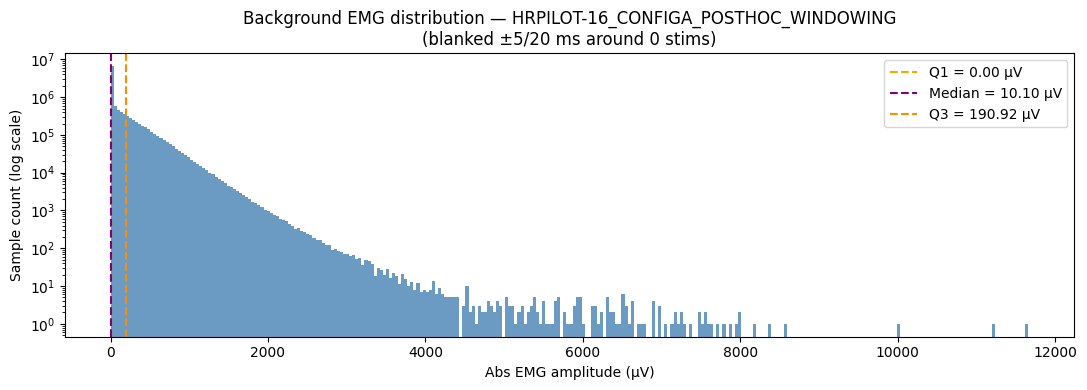


Section 4d: Per-trial pre-stim background grand means
  Trials : 2008
  Min=6.43  Q1=179.86  Median=277.37  Q3=341.62  Max=590.87
  Recorded thresholds (mean): [1.00, 499.70] µV


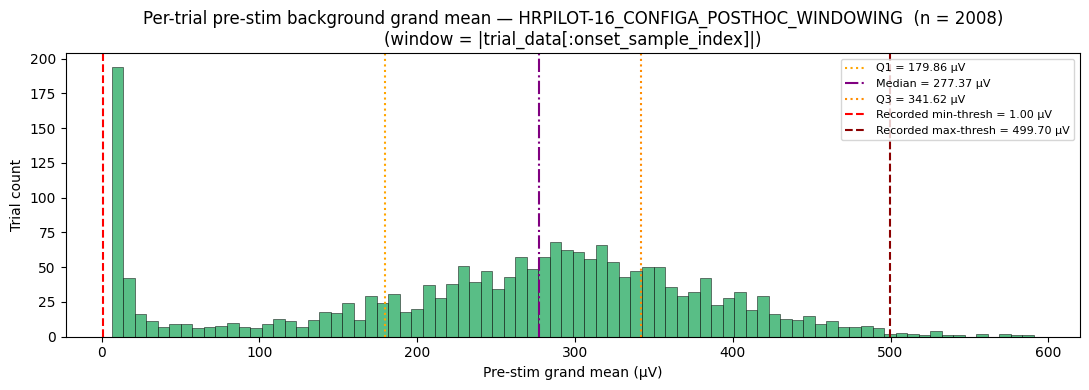

In [49]:
from helpers import (build_blank_mask, sweep_trials,
                     TRIAL_INIT_MIN_MS, TRIAL_INIT_MAX_MS)

if not hrs2_emg_blocks:
    print("No HRS2 EMG blocks available — skipping Section 4.")
else:
    # ── 4a: Sort and stitch HRS2 EMG blocks ─────────────────────────────────
    print("=" * 70)
    print("Section 4a: Reconstructing continuous signal from HRS2 EMG blocks")
    print("=" * 70)

    sorted_blks = sorted(hrs2_emg_blocks, key=lambda b: int(b.ts_open_ephys_sent))
    first_oe    = int(sorted_blks[0].ts_open_ephys_sent)
    last_blk    = sorted_blks[-1]
    last_oe     = int(last_blk.ts_open_ephys_sent) + len(last_blk.abs_val)
    n_total     = last_oe - first_oe

    sample_rate_hz = float(hrs1_header.sample_rate)
    duration_s     = n_total / sample_rate_hz

    continuous_abs_emg = np.zeros(n_total, dtype=np.float32)
    for blk in sorted_blks:
        i0 = int(blk.ts_open_ephys_sent) - first_oe
        i1 = i0 + len(blk.abs_val)
        if 0 <= i0 and i1 <= n_total:
            continuous_abs_emg[i0:i1] = blk.abs_val

    # Guarantee non-negative: abs-value the stitched signal before any analysis
    continuous_abs_emg = np.abs(continuous_abs_emg)

    timestamps_hrs2 = np.arange(n_total, dtype=np.float64) / sample_rate_hz

    # Check for inter-block gaps
    gap_samples = sum(
        max(0, int(sorted_blks[k].ts_open_ephys_sent) - (int(sorted_blks[k-1].ts_open_ephys_sent) + len(sorted_blks[k-1].abs_val)))
        for k in range(1, len(sorted_blks))
    )
    print(f"  Blocks stitched : {len(sorted_blks):,}")
    print(f"  Total samples   : {n_total:,}")
    print(f"  Duration        : {duration_s:.1f} s  ({duration_s / 60:.1f} min)")
    print(f"  OE sample range : {first_oe} – {last_oe}")
    print(f"  Gap samples     : {gap_samples:,}  ({100 * gap_samples / n_total:.3f}% of total)")

    # ── 4b: Blank mask around stimulation events ─────────────────────────────
    print("\n" + "=" * 70)
    print("Section 4b: Building blank mask around stimulation events")
    print("=" * 70)

    blank_pre_ms   = 5
    blank_post_ms  = 20
    min_valid_frac = 0.7

    stim_rel = []
    n_no_onset = 0
    for tr in hrs2_trials:
        fid = int(getattr(tr, 'first_post_trigger_frame_sample_id', 0))
        osi = int(getattr(tr, 'onset_sample_index', -1))
        if fid > 0 and osi >= 0:
            rel = fid + (osi - BIN_SAMPLES) - first_oe
            if 0 <= rel < n_total:
                stim_rel.append(rel)
            else:
                n_no_onset += 1
        else:
            n_no_onset += 1

    stim_times_s    = np.array(stim_rel, dtype=np.float64) / sample_rate_hz
    blank_mask_hrs2 = build_blank_mask(
        timestamps_hrs2, stim_times_s, sample_rate_hz, blank_pre_ms, blank_post_ms
    )
    print(f"  Stim events mapped  : {len(stim_rel)} of {len(hrs2_trials)}")
    print(f"  Unmapped (no onset) : {n_no_onset}")
    print(f"  Non-blanked samples : {blank_mask_hrs2.sum():,}  ({100 * blank_mask_hrs2.mean():.1f}%)")

    # ── 4c: Background EMG statistics ────────────────────────────────────────
    print("\n" + "=" * 70)
    print("Section 4c: Background EMG statistics (non-blanked samples)")
    print("=" * 70)

    bg_signal = continuous_abs_emg[blank_mask_hrs2]
    bg_mean   = float(np.mean(bg_signal))
    bg_std    = float(np.std(bg_signal))
    bg_q1, bg_med, bg_q3 = (float(x) for x in np.percentile(bg_signal, [25, 50, 75]))

    print(f"  n       : {len(bg_signal):,}")
    print(f"  Mean    : {bg_mean:.3f} µV")
    print(f"  Std     : {bg_std:.3f} µV")
    print(f"  Q1      : {bg_q1:.3f} µV")
    print(f"  Median  : {bg_med:.3f} µV")
    print(f"  Q3      : {bg_q3:.3f} µV")

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.hist(bg_signal, bins=300, color='steelblue', edgecolor='none', alpha=0.8)
    for val, lbl, col in [(bg_q1, 'Q1', 'orange'), (bg_med, 'Median', 'purple'), (bg_q3, 'Q3', 'darkorange')]:
        ax.axvline(val, color=col, linestyle='--', linewidth=1.5, label=f'{lbl} = {val:.2f} µV')
    ax.set_xlabel('Abs EMG amplitude (µV)')
    ax.set_ylabel('Sample count (log scale)')
    ax.set_yscale('log')
    ax.set_title(
        f'Background EMG distribution — {hrs2_header.subject_id}\n'
        f'(blanked ±{blank_pre_ms}/{blank_post_ms} ms around {len(stim_rel)} stims)'
    )
    ax.legend()
    plt.tight_layout()
    plt.show()

    # ── 4d: Per-trial pre-stim grand means ───────────────────────────────────
    print("\n" + "=" * 70)
    print("Section 4d: Per-trial pre-stim background grand means")
    print("=" * 70)

    trial_bg_gm  = []
    trial_min_th = []
    trial_max_th = []

    for tr in hrs2_trials:
        osi = int(getattr(tr, 'onset_sample_index', -1))
        pre = tr.trial_data[:osi] if osi > 0 else tr.trial_data[:BIN_SAMPLES]
        if len(pre) > 0:
            trial_bg_gm.append(float(np.mean(np.abs(pre))))
        trial_min_th.append(float(tr.min_initiation_threshold))
        trial_max_th.append(float(tr.max_initiation_threshold))

    trial_bg_gm  = np.array(trial_bg_gm,  dtype=np.float64)
    trial_min_th = np.array(trial_min_th, dtype=np.float64)
    trial_max_th = np.array(trial_max_th, dtype=np.float64)

    gm_q1, gm_med, gm_q3 = (float(x) for x in np.percentile(trial_bg_gm, [25, 50, 75]))

    print(f"  Trials : {len(trial_bg_gm)}")
    print(f"  Min={trial_bg_gm.min():.2f}  Q1={gm_q1:.2f}  Median={gm_med:.2f}  Q3={gm_q3:.2f}  Max={trial_bg_gm.max():.2f}")
    print(f"  Recorded thresholds (mean): [{trial_min_th.mean():.2f}, {trial_max_th.mean():.2f}] µV")

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.hist(trial_bg_gm, bins=80, color='mediumseagreen', edgecolor='black', linewidth=0.4, alpha=0.85)
    ax.axvline(gm_q1,  color='orange',  linestyle=':',  linewidth=1.5, label=f'Q1 = {gm_q1:.2f} µV')
    ax.axvline(gm_med, color='purple',  linestyle='-.', linewidth=1.5, label=f'Median = {gm_med:.2f} µV')
    ax.axvline(gm_q3,  color='darkorange', linestyle=':', linewidth=1.5, label=f'Q3 = {gm_q3:.2f} µV')
    ax.axvline(trial_min_th.mean(), color='red',     linestyle='--', linewidth=1.5,
               label=f'Recorded min-thresh = {trial_min_th.mean():.2f} µV')
    ax.axvline(trial_max_th.mean(), color='darkred', linestyle='--', linewidth=1.5,
               label=f'Recorded max-thresh = {trial_max_th.mean():.2f} µV')
    ax.set_xlabel('Pre-stim grand mean (µV)')
    ax.set_ylabel('Trial count')
    ax.set_title(
        f'Per-trial pre-stim background grand mean — {hrs2_header.subject_id}  (n = {len(trial_bg_gm)})\n'
        f'(window = |trial_data[:onset_sample_index]|)'
    )
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

# Section 5: Post-Hoc Threshold Sweep

Simulate the trial-initiation algorithm on the full continuous HRS2 background signal with different `(min_uv, max_uv)` threshold windows.

`sweep_trials()` walks the signal with randomised 2200–2700 ms monitoring windows — the same algorithm the app uses in real time.  We test window centres at **Q1**, **Median**, and **Q3** of the per-trial pre-stim background distribution, sweeping over a range of half-widths.

In [50]:
# ── Section 5a: Run threshold sweep ──────────────────────────────────────────
# Adjust `sweep_centres`, `half_widths_uv`, or add fixed windows to taste.

if 'gm_q1' not in dir():
    print("Run Section 4 first (cell above) to compute background statistics.")
else:
    print("=" * 70)
    print("Section 5a: Running post-hoc threshold sweep")
    print("=" * 70)
    print(f"Signal duration : {duration_s:.1f} s | Non-blanked: {100 * blank_mask_hrs2.mean():.1f}%")
    print(f"Background stats: mean={bg_mean:.2f}  Q1={gm_q1:.2f}  Med={gm_med:.2f}  Q3={gm_q3:.2f} µV\n")

    # Threshold window centres to test
    sweep_centres = {
        'Q1':     gm_q1,
        'Median': gm_med,
        'Q3':     gm_q3,
    }
    # Half-widths (µV) — each (centre ± hw) becomes one (min_uv, max_uv) pair
    half_widths_uv = [5, 10, 20, 30, 50, 75, 100, 150]

    sweep_results = {}
    for centre_label, centre_val in sweep_centres.items():
        sweep_results[centre_label] = []
        for hw in half_widths_uv:
            min_uv = max(0.0, centre_val - hw)
            max_uv = centre_val + hw
            accepted = sweep_trials(
                continuous_abs_emg, timestamps_hrs2, blank_mask_hrs2, sample_rate_hz,
                min_ms=TRIAL_INIT_MIN_MS, max_ms=TRIAL_INIT_MAX_MS,
                min_uv=min_uv, max_uv=max_uv,
                min_valid_fraction=min_valid_frac,
                seed=42,
            )
            sweep_results[centre_label].append({
                'hw': hw, 'min_uv': min_uv, 'max_uv': max_uv,
                'n_accepted': len(accepted),
            })

        row_str = '  '.join(
            f'±{r["hw"]}→{r["n_accepted"]}' for r in sweep_results[centre_label]
        )
        print(f"  {centre_label:6s} (centre={centre_val:.2f} µV):  {row_str}")

    print(f"\n  Actual HRS2 trials recorded during session: {len(hrs2_trials)}")

Section 5a: Running post-hoc threshold sweep
Signal duration : 2226.5 s | Non-blanked: 100.0%
Background stats: mean=144.21  Q1=179.86  Med=277.37  Q3=341.62 µV

  Q1     (centre=179.86 µV):  ±5→438  ±10→497  ±20→575  ±30→624  ±50→696  ±75→746  ±100→769  ±150→798
  Median (centre=277.37 µV):  ±5→10  ±10→14  ±20→28  ±30→48  ±50→125  ±75→288  ±100→500  ±150→709
  Q3     (centre=341.62 µV):  ±5→1  ±10→1  ±20→1  ±30→1  ±50→2  ±75→14  ±100→67  ±150→378

  Actual HRS2 trials recorded during session: 2008


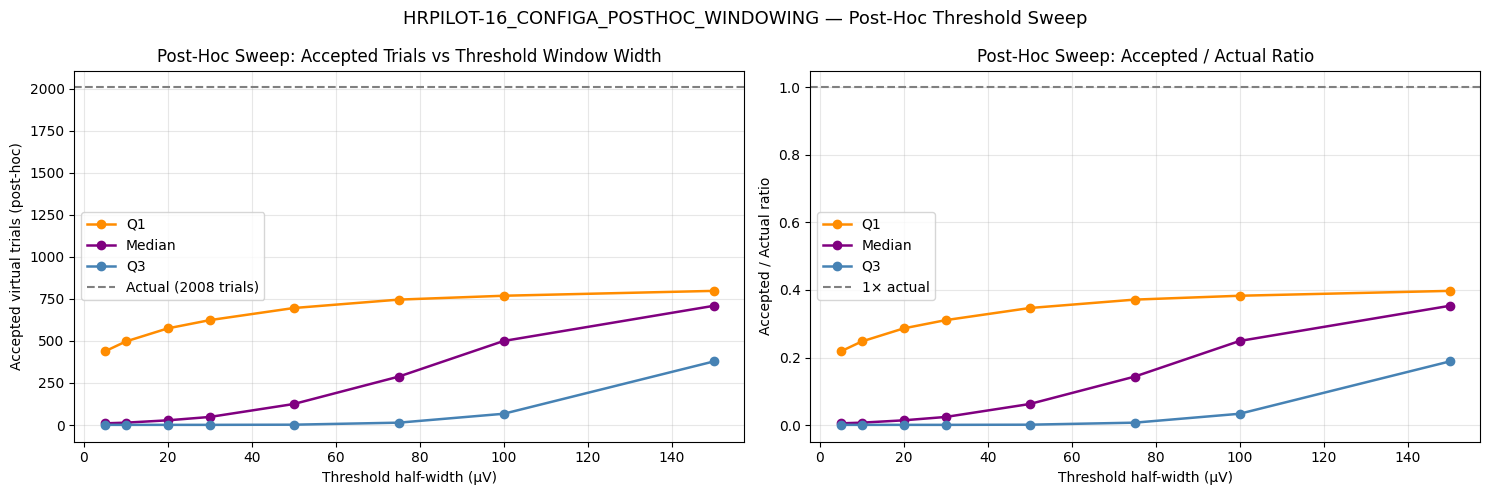

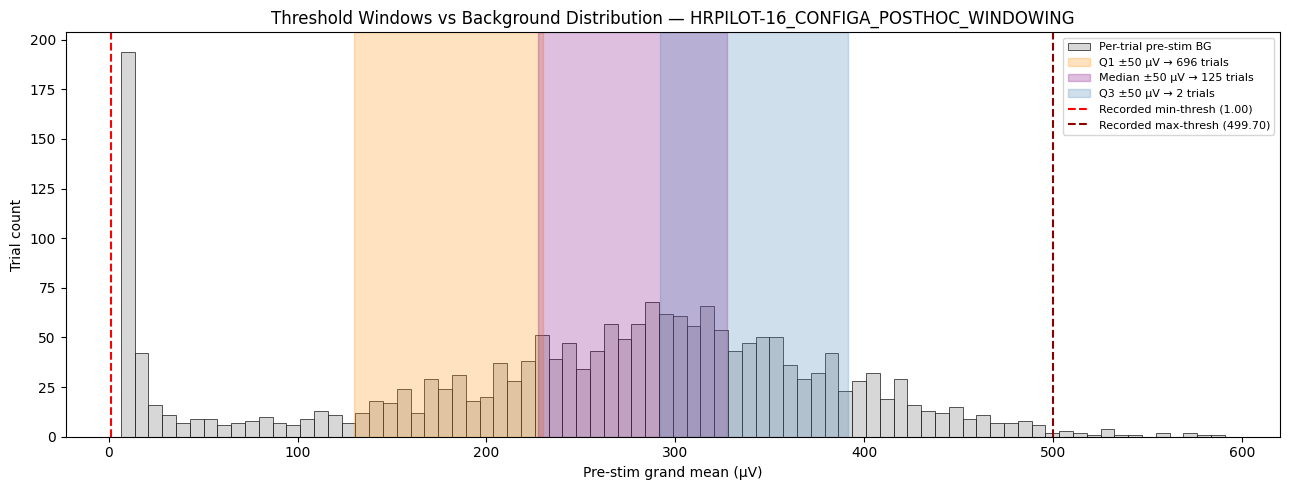


    Centre   ±hw (µV)   Min (µV)   Max (µV)   Accepted    vs Actual
-------------------------------------------------------------------
        Q1          5     174.86     184.86        438        0.22×
        Q1         10     169.86     189.86        497        0.25×
        Q1         20     159.86     199.86        575        0.29×
        Q1         30     149.86     209.86        624        0.31×
        Q1         50     129.86     229.86        696        0.35×
        Q1         75     104.86     254.86        746        0.37×
        Q1        100      79.86     279.86        769        0.38×
        Q1        150      29.86     329.86        798        0.40×

    Median          5     272.37     282.37         10        0.00×
    Median         10     267.37     287.37         14        0.01×
    Median         20     257.37     297.37         28        0.01×
    Median         30     247.37     307.37         48        0.02×
    Median         50     227.37     327.37   

In [52]:
# ── Section 5b: Visualise threshold sweep results ────────────────────────────
if 'sweep_results' not in dir() or not sweep_results:
    print("Run the threshold sweep cell above first.")
else:
    colours = {'Q1': 'darkorange', 'Median': 'purple', 'Q3': 'steelblue'}

    # ── Panel 1+2: accepted trials and ratio vs half-width ───────────────────
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    ax = axes[0]
    for label, rows in sweep_results.items():
        hws = [r['hw'] for r in rows]
        ns  = [r['n_accepted'] for r in rows]
        ax.plot(hws, ns, 'o-', label=label, color=colours[label], linewidth=1.8)
    ax.axhline(len(hrs2_trials), color='gray', linestyle='--', linewidth=1.5,
               label=f'Actual ({len(hrs2_trials)} trials)')
    ax.set_xlabel('Threshold half-width (µV)')
    ax.set_ylabel('Accepted virtual trials (post-hoc)')
    ax.set_title('Post-Hoc Sweep: Accepted Trials vs Threshold Window Width')
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax2 = axes[1]
    for label, rows in sweep_results.items():
        hws   = [r['hw'] for r in rows]
        ratio = [r['n_accepted'] / max(len(hrs2_trials), 1) for r in rows]
        ax2.plot(hws, ratio, 'o-', label=label, color=colours[label], linewidth=1.8)
    ax2.axhline(1.0, color='gray', linestyle='--', linewidth=1.5, label='1× actual')
    ax2.set_xlabel('Threshold half-width (µV)')
    ax2.set_ylabel('Accepted / Actual ratio')
    ax2.set_title('Post-Hoc Sweep: Accepted / Actual Ratio')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle(f'{hrs2_header.subject_id} — Post-Hoc Threshold Sweep', fontsize=13)
    plt.tight_layout()
    plt.show()

    # ── Panel 3: threshold windows on background histogram ───────────────────
    fig2, ax3 = plt.subplots(figsize=(13, 5))
    ax3.hist(trial_bg_gm, bins=80, color='lightgray', edgecolor='black',
             linewidth=0.5, alpha=0.9, label='Per-trial pre-stim BG')
    for label, rows in sweep_results.items():
        col     = colours[label]
        mid_row = rows[len(rows) // 2]
        ax3.axvspan(mid_row['min_uv'], mid_row['max_uv'], alpha=0.25, color=col,
                    label=f"{label} ±{mid_row['hw']} µV → {mid_row['n_accepted']} trials")
    ax3.axvline(trial_min_th.mean(), color='red',     linestyle='--', linewidth=1.5,
                label=f"Recorded min-thresh ({trial_min_th.mean():.2f})")
    ax3.axvline(trial_max_th.mean(), color='darkred', linestyle='--', linewidth=1.5,
                label=f"Recorded max-thresh ({trial_max_th.mean():.2f})")
    ax3.set_xlabel('Pre-stim grand mean (µV)')
    ax3.set_ylabel('Trial count')
    ax3.set_title(f'Threshold Windows vs Background Distribution — {hrs2_header.subject_id}')
    ax3.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    # ── Summary table ─────────────────────────────────────────────────────────
    print(f"\n{'Centre':>10} {'±hw (µV)':>10} {'Min (µV)':>10} {'Max (µV)':>10} {'Accepted':>10} {'vs Actual':>12}")
    print("-" * 67)
    for label, rows in sweep_results.items():
        for r in rows:
            ratio_s = f"{r['n_accepted'] / max(len(hrs2_trials), 1):.2f}×"
            print(f"{label:>10} {r['hw']:>10} {r['min_uv']:>10.2f} {r['max_uv']:>10.2f} "
                  f"{r['n_accepted']:>10} {ratio_s:>12}")
        print()